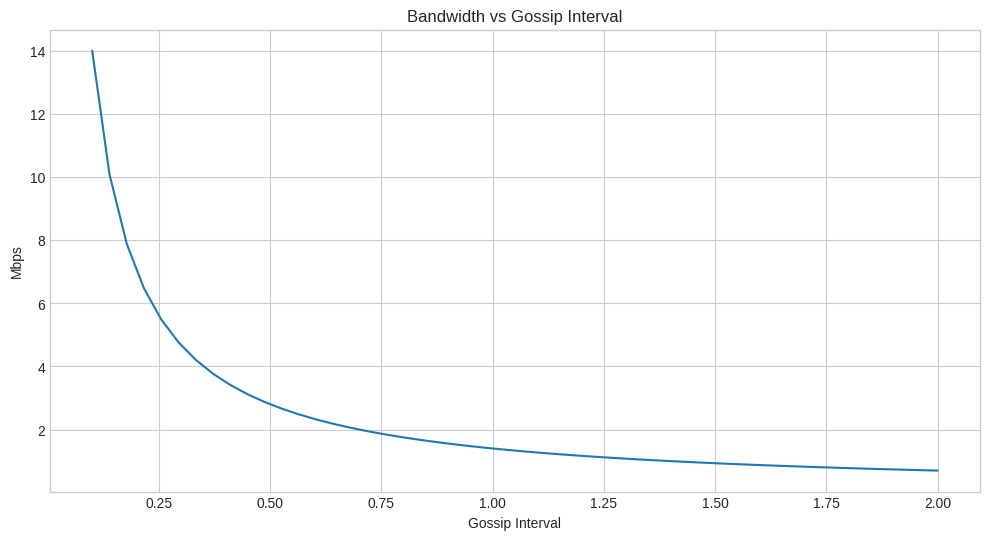

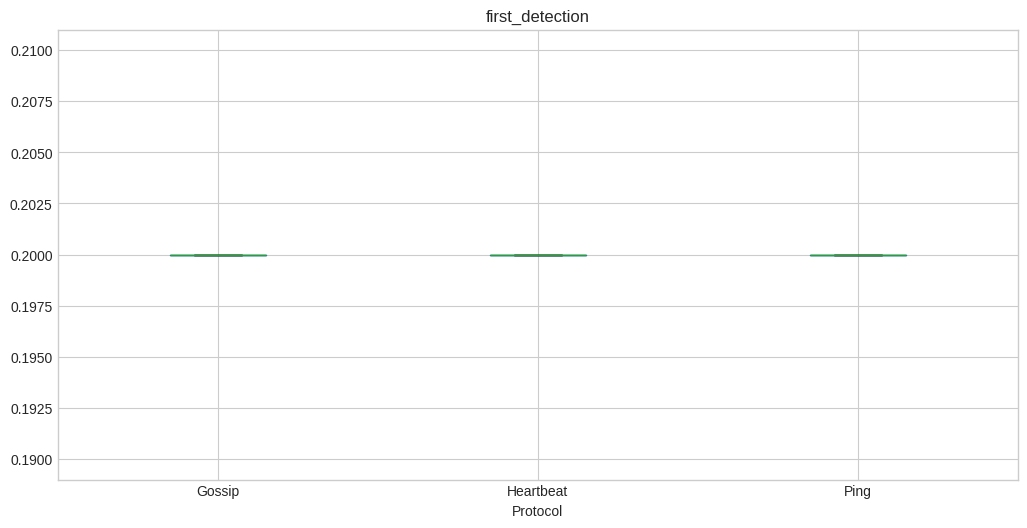

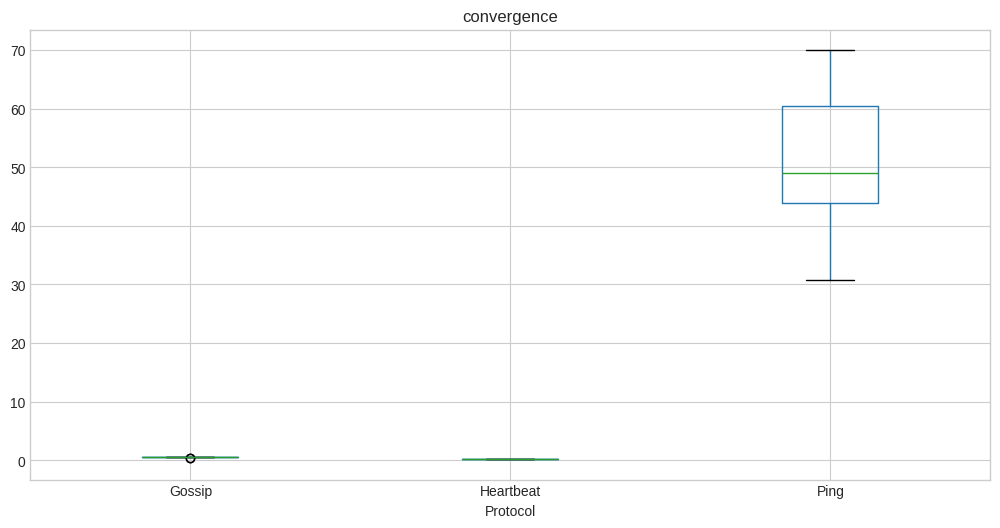

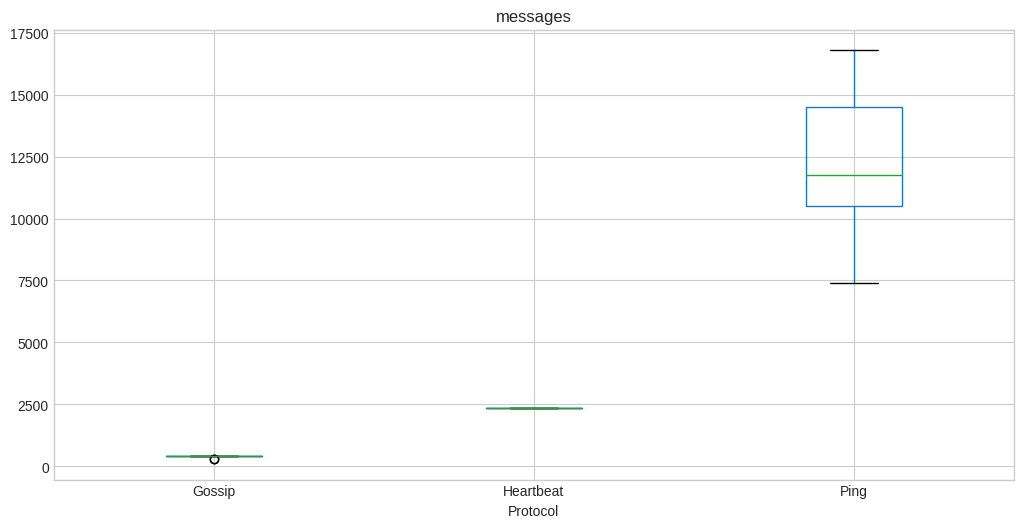

           first_detection  convergence  messages
Protocol                                         
Gossip                 0.2         0.58     417.6
Heartbeat              0.2         0.20    2352.0
Ping                   0.2        51.07   12256.8


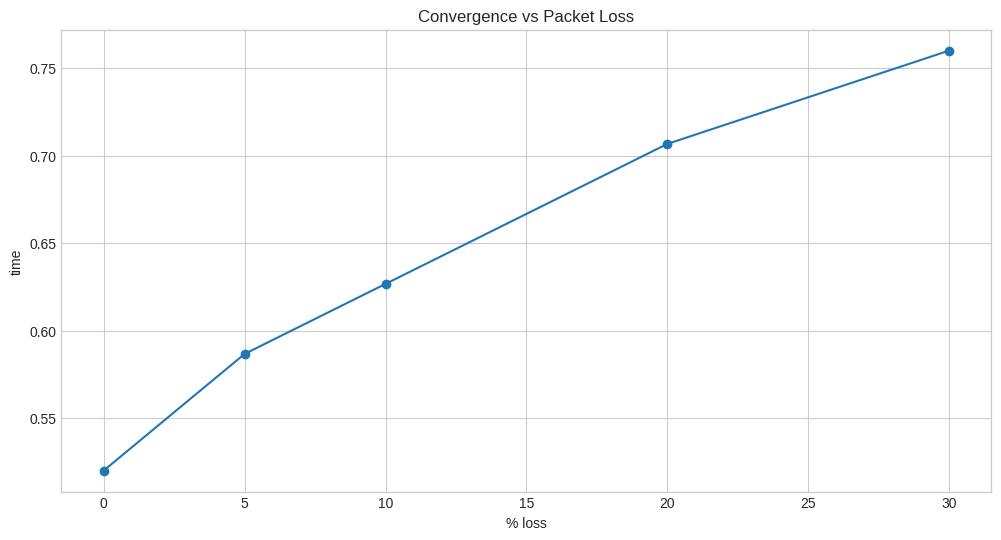

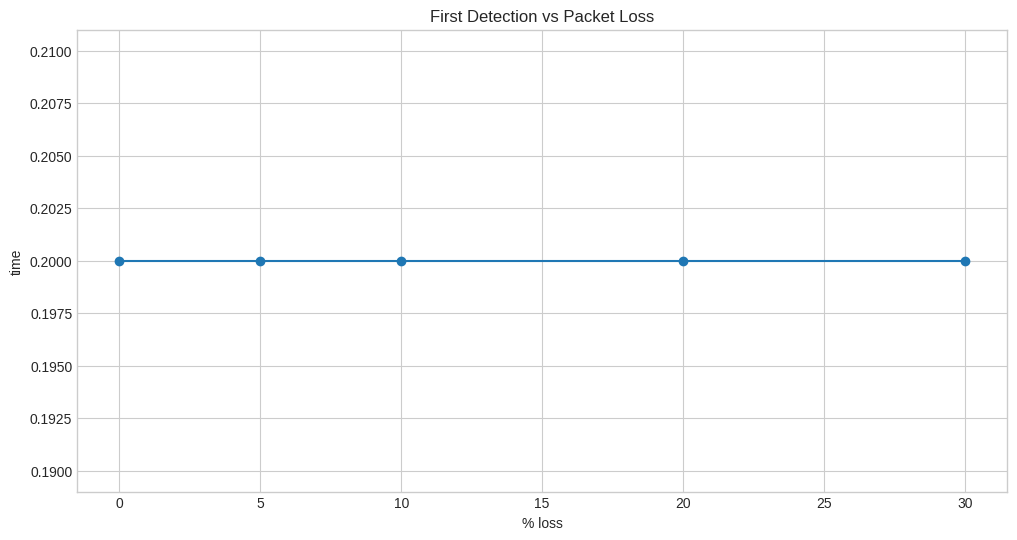

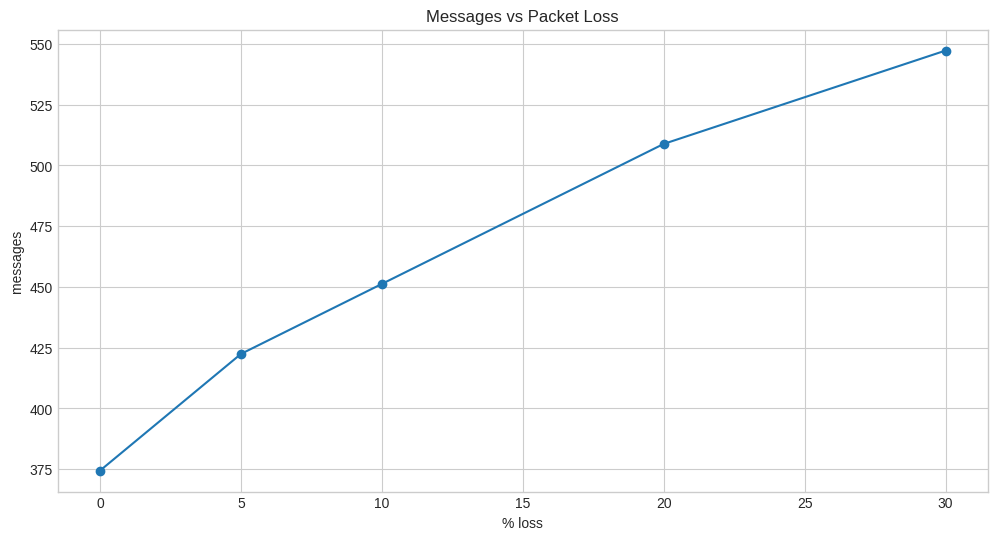

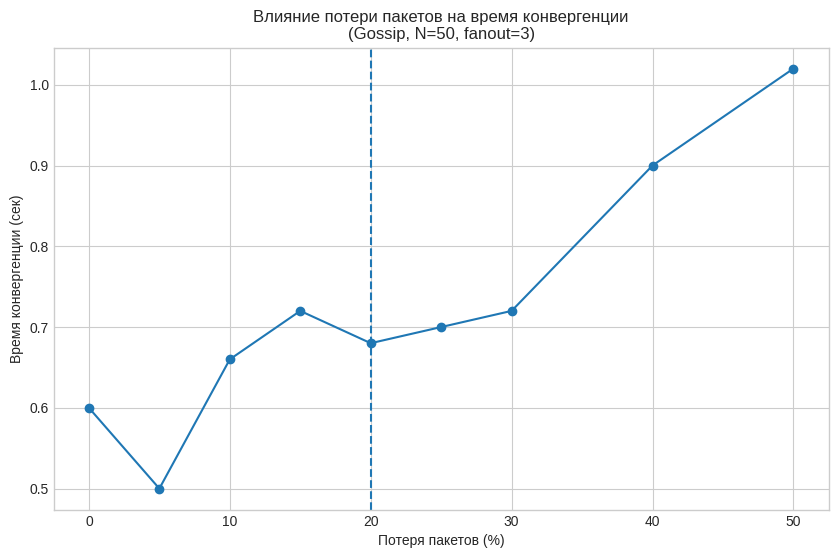

In [4]:
# ==================== Импорт ====================
import random
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from abc import ABC, abstractmethod

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# ==================== Bandwidth ====================
def calculate_bandwidth(gossip_interval, gossip_fanout, nodes, node_failures):
    PACKET_SIZE = 1024
    OVERHEAD = 1.2

    active_nodes = nodes * (1 - node_failures)
    messages_per_second = (1 / gossip_interval) * gossip_fanout * active_nodes

    data_per_second = messages_per_second * PACKET_SIZE * OVERHEAD
    return data_per_second * 8


# ==================== График Bandwidth ====================
intervals = np.linspace(0.1, 2.0, 50)
bandwidths = [calculate_bandwidth(t, 3, 50, 0.05)/1e6 for t in intervals]

plt.plot(intervals, bandwidths)
plt.xlabel("Gossip Interval")
plt.ylabel("Mbps")
plt.title("Bandwidth vs Gossip Interval")
plt.show()


# ==================== БАЗОВЫЙ КЛАСС ====================
class FailureDetector(ABC):
    def __init__(self, N, failure_rate, interval=0.2):
        self.N = N
        self.failure_rate = failure_rate
        self.interval = interval

        self.alive = [True]*N
        self.failed_nodes = set()
        self.knowledge = [[True]*N for _ in range(N)]

        self.time = 0
        self.total_messages = 0

    def inject_failures(self):
        num_fail = int(self.N * self.failure_rate)
        nodes = list(range(self.N))
        random.shuffle(nodes)

        self.failed_nodes = set(nodes[:num_fail])

        for f in self.failed_nodes:
            self.alive[f] = False

        # стартовое знание
        alive_nodes = [i for i in range(self.N) if self.alive[i]]
        if alive_nodes:
            first = alive_nodes[0]
            for f in self.failed_nodes:
                self.knowledge[first][f] = False

    @abstractmethod
    def step(self):
        pass

    def run(self, max_steps=500):
        self.inject_failures()

        first_detection = None
        convergence = None

        for _ in range(max_steps):
            self.time += self.interval
            msgs = self.step()
            self.total_messages += msgs

            # first detection
            if first_detection is None:
                for i in range(self.N):
                    if self.alive[i]:
                        if any(not self.knowledge[i][f] for f in self.failed_nodes):
                            first_detection = self.time
                            break

            # convergence
            all_know = True
            for i in range(self.N):
                if self.alive[i]:
                    if any(self.knowledge[i][f] for f in self.failed_nodes):
                        all_know = False
                        break

            if all_know:
                convergence = self.time
                break

        return {
            "first_detection": first_detection or self.time,
            "convergence": convergence or self.time,
            "messages": self.total_messages
        }


# ==================== Gossip ====================
class SerfSimulator(FailureDetector):
    def __init__(self, N, failure_rate, interval=0.2, fanout=3, packet_loss=0):
        super().__init__(N, failure_rate, interval)
        self.fanout = fanout
        self.packet_loss = packet_loss

    def step(self):
        msgs = 0
        for i in range(self.N):
            if not self.alive[i]:
                continue

            targets = random.sample(
                [j for j in range(self.N) if j != i and self.alive[j]],
                min(self.fanout, self.N-1)
            )

            for t in targets:
                msgs += 1

                if random.random() < self.packet_loss:
                    continue

                for k in range(self.N):
                    if not self.knowledge[i][k]:
                        self.knowledge[t][k] = False

        return msgs


# ==================== Heartbeat ====================
class HeartbeatSimulator(FailureDetector):
    def step(self):
        msgs = 0
        for i in range(self.N):
            if not self.alive[i]:
                continue

            for j in range(self.N):
                if i != j:
                    msgs += 1
                    self.knowledge[i][j] = self.alive[j]

        return msgs


# ==================== Ping ====================
class PingSimulator(FailureDetector):
    def step(self):
        msgs = 0
        for i in range(self.N):
            if not self.alive[i]:
                continue

            target = random.choice([j for j in range(self.N) if j != i])
            msgs += 1

            self.knowledge[i][target] = self.alive[target]

        return msgs


# ==================== СРАВНЕНИЕ ====================
def experiment(sim, runs=20):
    res = []
    for _ in range(runs):
        r = sim().run()
        res.append(r)
    return pd.DataFrame(res)


N = 50
fail = 0.05

df_serf = experiment(lambda: SerfSimulator(N, fail))
df_hb   = experiment(lambda: HeartbeatSimulator(N, fail))
df_ping = experiment(lambda: PingSimulator(N, fail))

df_serf["Protocol"] = "Gossip"
df_hb["Protocol"] = "Heartbeat"
df_ping["Protocol"] = "Ping"

df = pd.concat([df_serf, df_hb, df_ping])

# boxplot
for metric in ["first_detection", "convergence", "messages"]:
    df.boxplot(column=metric, by="Protocol")
    plt.title(metric)
    plt.suptitle("")
    plt.show()


print(df.groupby("Protocol").mean())


# ==================== VARIANT 4 ====================
packet_losses = [0, 0.05, 0.1, 0.2, 0.3]

conv = []
first = []
msgs = []

for pl in packet_losses:
    c, f, m = [], [], []

    for _ in range(15):
        sim = SerfSimulator(N, fail, packet_loss=pl)
        r = sim.run()

        c.append(r["convergence"])
        f.append(r["first_detection"])
        m.append(r["messages"])

    conv.append(np.mean(c))
    first.append(np.mean(f))
    msgs.append(np.mean(m))


# графики
x = [int(p*100) for p in packet_losses]

plt.plot(x, conv, marker='o')
plt.title("Convergence vs Packet Loss")
plt.xlabel("% loss")
plt.ylabel("time")
plt.show()

plt.plot(x, first, marker='o')
plt.title("First Detection vs Packet Loss")
plt.xlabel("% loss")
plt.ylabel("time")
plt.show()

plt.plot(x, msgs, marker='o')
plt.title("Messages vs Packet Loss")
plt.xlabel("% loss")
plt.ylabel("messages")
plt.show()


def study_packet_loss_effect():
    packet_losses = [0, 5, 10, 15, 20, 25, 30, 40, 50]

    nodes = 50
    interval = 0.2
    fanout = 3
    failure_rate = 0.05

    convergence_times = []

    for pl in packet_losses:
        times = []

        for _ in range(10):  # чуть больше прогонов для стабильности
            sim = SerfSimulator(
                N=nodes,
                failure_rate=failure_rate,
                interval=interval,
                fanout=fanout,
                packet_loss=pl / 100
            )

            res = sim.run()
            times.append(res["convergence"])

        convergence_times.append(np.mean(times))

    # График
    plt.figure(figsize=(10, 6))
    plt.plot(packet_losses, convergence_times, marker='o')
    plt.xlabel('Потеря пакетов (%)')
    plt.ylabel('Время конвергенции (сек)')
    plt.title('Влияние потери пакетов на время конвергенции\n(Gossip, N=50, fanout=3)')
    plt.grid(True)

    # "критическая зона"
    plt.axvline(x=20, linestyle='--')

    plt.show()

    return packet_losses, convergence_times


pl_list, conv_times_pl = study_packet_loss_effect()